In [8]:
import gc

import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange, set_num_threads, get_num_threads
from scipy.ndimage import maximum_filter, median_filter
from scipy.optimize import curve_fit


In [9]:
# configuration
num_threads = 16

# numerical grid
eps = 1e-4
w0_min = -5.0
w0_max = 5.0
n_w0 = 5_000
w0_imag = 10.0
w0_arr = np.linspace(w0_min, w0_max, n_w0) + 1j * w0_imag

# model parameters
a_values = np.linspace(1.0, 100.0, 51)
a = a_values[0]
m = 0.05
iter_range = 20
n_step = int(iter_range / m) + 1

# stability controls
denom_floor = 1e-12
g_abs_max = 1e12

# pole detection and sweep controls
pole_sensitivity = 0.01  # 0.0 = strict/fewer poles, 1.0 = sensitive/more poles
scan_stride = 10

set_num_threads(num_threads)
print(f"numba threads: {get_num_threads()}")
print(f"n_step: {n_step}")


numba threads: 16
n_step: 401


In [10]:
def pole_detection_config(sensitivity):
    """Convert a single sensitivity knob into pole-selection parameters."""
    sensitivity = float(np.clip(sensitivity, 0.0, 1.0))
    return {
        'peak_window': 7 if sensitivity < 0.25 else 5 if sensitivity < 0.65 else 3,
        'background_window': 31 if sensitivity < 0.25 else 21 if sensitivity < 0.65 else 15,
        'strength_percentile': 99.3 - 2.3 * sensitivity,
        'prominence_percentile': 99.0 - 4.0 * sensitivity,
        'min_separation': 0.12 - 0.08 * sensitivity,
    }

pole_config = pole_detection_config(pole_sensitivity)
print('pole detection config:')
for key, value in pole_config.items():
    print(f'  {key}: {value}')


pole detection config:
  peak_window: 7
  background_window: 31
  strength_percentile: 99.277
  prominence_percentile: 98.96
  min_separation: 0.1192


In [11]:
@njit(parallel=True)
def g_iterator(w0_arr, a, eps, m, max_iter, denom_floor=1e-12, g_abs_max=1e12):
    n_w = len(w0_arr)
    g_arr = np.empty((n_w, max_iter), dtype=np.complex128)
    w_arr = np.empty((n_w, max_iter), dtype=np.complex128)
    nan_value = np.nan + 1j * np.nan

    # Each starting w value is independent, so this is the safe parallel axis.
    for j in prange(n_w):
        w = w0_arr[j]
        g = 1j / (w + 1j * eps)

        g_arr[j, 0] = g
        w_arr[j, 0] = w

        for i in range(1, max_iter):
            g_abs = abs(g)
            denom = 1j * a * g - 1j * w
            denom_abs = abs(denom)

            if (
                not np.isfinite(g_abs)
                or not np.isfinite(denom_abs)
                or denom_abs < denom_floor
                or g_abs > g_abs_max
            ):
                for k in range(i, max_iter):
                    g_arr[j, k] = nan_value
                    w_arr[j, k] = w
                    w = w - 1j * m
                break

            g = 1 / denom
            w = w - 1j * m

            g_arr[j, i] = g
            w_arr[j, i] = w

    return g_arr, w_arr


In [12]:
def compute_log_abs_g(g_arr):
    abs_g = np.abs(g_arr)
    finite = np.isfinite(abs_g)
    log_abs_g = np.full(abs_g.shape, np.nan, dtype=float)
    log_abs_g[finite] = np.log10(np.maximum(abs_g[finite], np.finfo(float).tiny))
    return log_abs_g, finite


def find_poles(g_arr, w_arr, config):
    log_abs_g, finite = compute_log_abs_g(g_arr)
    if not np.any(finite):
        return np.array([], dtype=complex), np.array([]), log_abs_g

    finite_floor = np.nanmin(log_abs_g) - 1.0
    filtered_log_abs_g = np.where(np.isfinite(log_abs_g), log_abs_g, finite_floor)

    local_max = filtered_log_abs_g == maximum_filter(
        filtered_log_abs_g,
        size=config['peak_window'],
    )
    local_background = median_filter(
        filtered_log_abs_g,
        size=config['background_window'],
    )
    prominence = filtered_log_abs_g - local_background

    strength_cutoff = np.nanpercentile(log_abs_g, config['strength_percentile'])
    prominence_cutoff = np.nanpercentile(prominence, config['prominence_percentile'])
    is_peak = (
        finite
        & local_max
        & (log_abs_g > strength_cutoff)
        & (prominence > prominence_cutoff)
    )

    candidate_i, candidate_j = np.where(is_peak)
    candidate_w = w_arr[candidate_i, candidate_j]
    candidate_strength = log_abs_g[candidate_i, candidate_j]
    order = np.argsort(candidate_strength)[::-1]

    selected_w = []
    selected_strength = []
    for idx in order:
        w = candidate_w[idx]
        if all(abs(w - kept_w) >= config['min_separation'] for kept_w in selected_w):
            selected_w.append(w)
            selected_strength.append(candidate_strength[idx])

    return np.array(selected_w, dtype=complex), np.array(selected_strength), log_abs_g


def exp_decay(t, amplitude, gamma):
    return amplitude * np.exp(-gamma * t)


def fit_gamma_from_poles(pole_w, t_max=10):
    decaying_poles = pole_w[pole_w.imag <= 0]
    if len(decaying_poles) < 3:
        return np.nan, np.nan, None, None, None

    time = np.linspace(0, t_max, len(decaying_poles))
    decay_curves = np.array([np.sum(np.exp(decaying_poles.imag * t)) for t in time])
    valid = np.isfinite(decay_curves) & (decay_curves > 0)
    fit_time = time[valid]
    fit_decay = decay_curves[valid]
    if len(fit_decay) < 3:
        return np.nan, np.nan, time, decay_curves, None

    p0 = [fit_decay[0], max(-np.max(decaying_poles.imag), 1e-12)]
    params, covariance = curve_fit(
        exp_decay,
        fit_time,
        fit_decay,
        p0=p0,
        bounds=([0, 0], [np.inf, np.inf]),
        maxfev=10_000,
    )
    gamma = params[1]
    gamma_err = np.sqrt(covariance[1, 1])
    return gamma, gamma_err, time, decay_curves, exp_decay(time, *params)


def fit_power_law(a_values, gamma_values, gamma_errors):
    valid = np.isfinite(gamma_values) & (gamma_values > 0) & (a_values > 0)
    fit_a = a_values[valid]
    fit_gamma = gamma_values[valid]
    fit_gamma_err = gamma_errors[valid]
    if len(fit_gamma) < 3:
        return np.nan, np.nan, np.nan, np.nan, fit_a, fit_gamma

    log_a = np.log(fit_a)
    log_gamma = np.log(fit_gamma)
    log_gamma_err = fit_gamma_err / fit_gamma
    use_weights = np.all(np.isfinite(log_gamma_err) & (log_gamma_err > 0))
    kwargs = {'sigma': log_gamma_err, 'absolute_sigma': True} if use_weights else {}

    params, covariance = curve_fit(
        lambda log_a, log_C, x: log_C + x * log_a,
        log_a,
        log_gamma,
        p0=[0.0, 0.5],
        maxfev=10_000,
        **kwargs,
    )
    log_C, x = params
    log_C_err, x_err = np.sqrt(np.diag(covariance))
    C = np.exp(log_C)
    C_err = C * log_C_err
    return C, C_err, x, x_err, fit_a, fit_gamma


def power_law(a, C, x):
    return C * a ** x


def sweep_gamma_vs_a(a_values, scan_w0_arr, config):
    gamma_values = np.empty(len(a_values), dtype=np.float64)
    gamma_errors = np.empty(len(a_values), dtype=np.float64)

    for idx, a_i in enumerate(a_values):
        scan_g_arr, scan_w_arr = g_iterator(
            scan_w0_arr,
            a_i,
            eps,
            m,
            n_step,
            denom_floor,
            g_abs_max,
        )
        scan_pole_w, _, _ = find_poles(scan_g_arr, scan_w_arr, config)
        gamma_values[idx], gamma_errors[idx], _, _, _ = fit_gamma_from_poles(scan_pole_w)

        del scan_g_arr, scan_w_arr
        gc.collect()

    return gamma_values, gamma_errors


In [13]:
def plot_g_heatmap(w_arr, g_arr, xlim=(-1.5, 1.5), ylim=(-3.0, 1.0)):
    z = g_arr.real
    finite_z = z[np.isfinite(z)]
    vmax = np.nanpercentile(np.abs(finite_z), 98) if len(finite_z) else 1.0

    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    heatmap = ax.pcolormesh(
        w_arr.real,
        w_arr.imag,
        z,
        cmap='coolwarm',
        shading='auto',
        vmin=-vmax,
        vmax=vmax,
    )
    fig.colorbar(heatmap, ax=ax, pad=0.02, label='Real part of g')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel('Real part of w')
    ax.set_ylabel('Imaginary part of w')
    ax.set_title('Iterative Solution of g')
    plt.show()


def plot_poles(w_arr, log_abs_g, pole_w, xlim=(-1.5, 1.5), ylim=(-3.0, 1.0)):
    vmin, vmax = np.nanpercentile(log_abs_g, [5, 99.8])

    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    heatmap = ax.pcolormesh(
        w_arr.real,
        w_arr.imag,
        log_abs_g,
        cmap='magma',
        shading='auto',
        vmin=vmin,
        vmax=vmax,
    )
    ax.scatter(
        pole_w.real,
        pole_w.imag,
        s=35,
        facecolors='none',
        edgecolors='cyan',
        linewidths=1.2,
        label='pole candidates',
    )
    fig.colorbar(heatmap, ax=ax, label='log10(|g|)')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel('Real part of w')
    ax.set_ylabel('Imaginary part of w')
    ax.set_title('Pole Candidates from Prominent Local Peaks')
    ax.legend(loc='upper right')
    plt.show()


def plot_decay_fit(gamma, time, decay_curves, fit_curve):
    if time is None:
        print('not enough decaying poles for gamma fit')
        return

    plt.plot(time, decay_curves, label='summed pole decay')
    if fit_curve is not None:
        plt.plot(time, fit_curve, '--', label=f'fit: gamma = {gamma:.4f}')
    plt.xlabel('Time')
    plt.ylabel('Decay')
    plt.title('Exponential Fit from Pole Candidates')
    plt.legend()
    plt.grid()
    plt.show()


def plot_a_gamma_fit(a_values, gamma_values, gamma_errors, C, x, fit_a):
    plt.errorbar(
        a_values,
        gamma_values,
        yerr=gamma_errors,
        fmt='.',
        linestyle='none',
        capsize=4,
        label='data',
    )
    if np.isfinite(C) and np.isfinite(x):
        a_fit = np.linspace(fit_a.min(), fit_a.max(), 500)
        plt.plot(a_fit, power_law(a_fit, C, x), '--', label=f'fit: gamma = {C:.3f} a^{x:.3f}')
    plt.xlabel('a')
    plt.ylabel('fitted gamma')
    plt.title('a vs fitted gamma')
    plt.grid(True, which='both')
    plt.legend()
    plt.show()


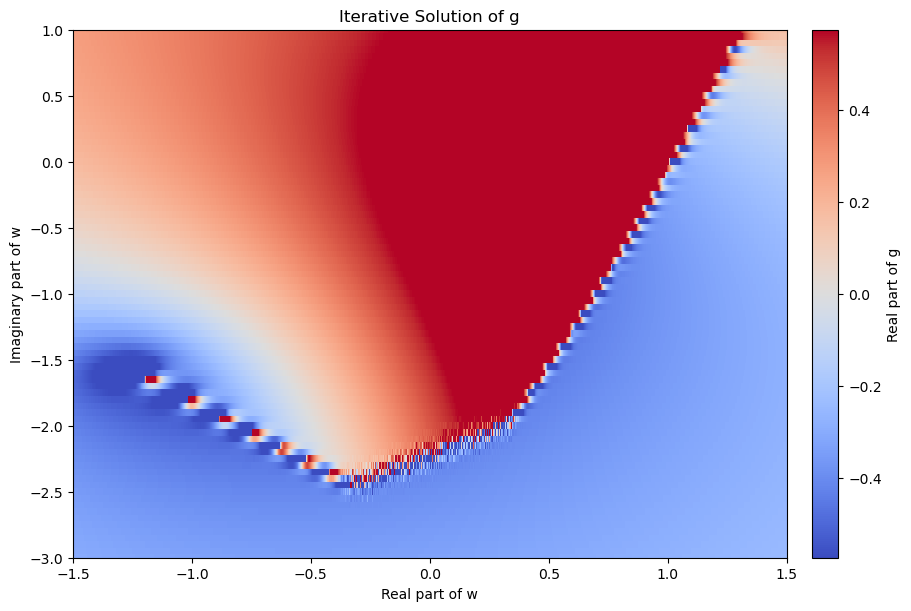

Found 28 pole candidates


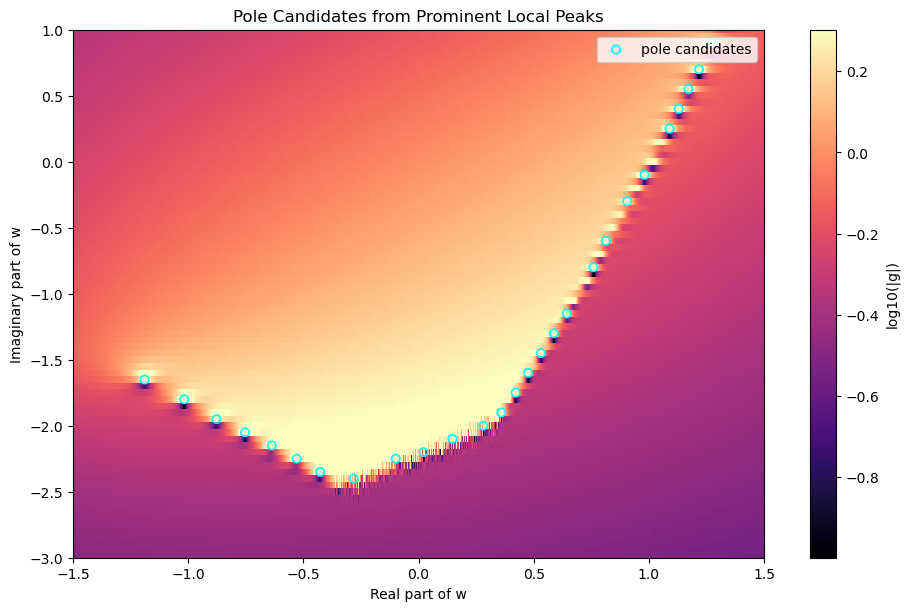

In [14]:
# single run
g_arr, w_arr = g_iterator(w0_arr, a, eps, m, n_step, denom_floor, g_abs_max)
plot_g_heatmap(w_arr, g_arr)

pole_w, pole_strength, log_abs_g = find_poles(g_arr, w_arr, pole_config)
print(f'Found {len(pole_w)} pole candidates')
plot_poles(w_arr, log_abs_g, pole_w)


gamma = 1.271340 +/- 0.082232


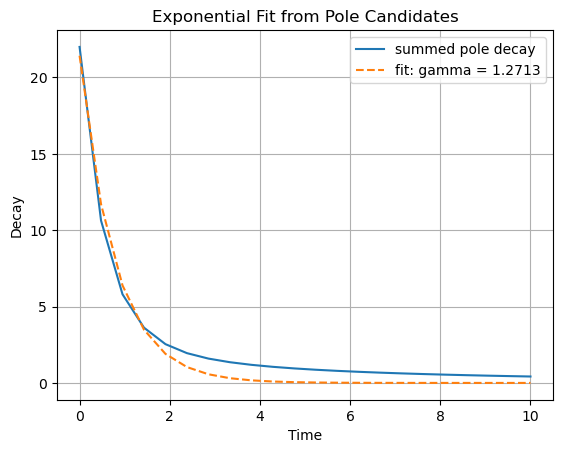

In [15]:
# gamma fit for single run
gamma, gamma_err, time, decay_curves, fit_curve = fit_gamma_from_poles(pole_w)
print(f'gamma = {gamma:.6f} +/- {gamma_err:.6f}')
plot_decay_fit(gamma, time, decay_curves, fit_curve)


log-space power-law fit: gamma = 1.445093 * a^0.295870
C = 1.445093 +/- 0.030071
x = 0.295870 +/- 0.005016


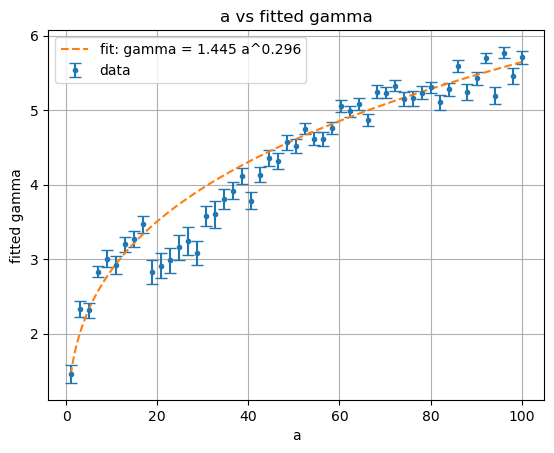

In [16]:
# sweep a and fit gamma = C * a^x
scan_w0_arr = w0_arr[::scan_stride]
gamma_values, gamma_errors = sweep_gamma_vs_a(a_values, scan_w0_arr, pole_config)
C, C_err, x, x_err, fit_a, fit_gamma = fit_power_law(a_values, gamma_values, gamma_errors)

if np.isfinite(C) and np.isfinite(x):
    print(f'log-space power-law fit: gamma = {C:.6f} * a^{x:.6f}')
    print(f'C = {C:.6f} +/- {C_err:.6f}')
    print(f'x = {x:.6f} +/- {x_err:.6f}')
else:
    print('not enough valid gamma values for power-law fit')

plot_a_gamma_fit(a_values, gamma_values, gamma_errors, C, x, fit_a)
